# NSL-KDD Network Intrusion Detection — Binary Classification

**Task:** Normal (0) vs Anomaly/Attack (1)  
**Database:** `nsl_kdd`  
**Tables:** `nsl_kdd_common_train_clean` · `nsl_kdd_common_test_clean`  
**Models:** Logistic Regression · Naive Bayes · KNN · Decision Tree · Random Forest · SVM  
**Imbalance fix:** Random oversampling via `sklearn.utils.resample` (9.4:1 → 1:1)

---
## 1. Environment Check

In [32]:
!python --version

Python 3.13.9


---
## 2. Install Dependencies

In [33]:
%conda install -c anaconda mysql-connector-python -y

3 channel Terms of Service accepted
Channels:
 - anaconda
 - defaults
Platform: win-64
Solving environment: done

# All requested packages already installed.


Note: you may need to restart the kernel to use updated packages.




==> WARNING: A newer version of conda exists. <==
    current version: 26.1.1
    latest version: 26.3.2

Please update conda by running

    $ conda update -n base -c defaults conda




In [34]:
!pip install scikit-learn pandas numpy matplotlib seaborn --quiet

---
## 3. MySQL Connection

In [35]:
import mysql.connector as sql

conn = sql.connect(
    host     = 'localhost',
    port     = 3305,        
    user     = 'root',
    password = 'bob123',
    database = 'nsl_kdd',
    use_pure = True
)
conn

In [36]:
cursor = conn.cursor(buffered=True)
cursor.execute('USE nsl_kdd')
cursor.execute('SHOW TABLES')
for x in cursor:
    print(x)

('nsl_kdd_common_test_clean',)
('nsl_kdd_common_train_clean',)


---
## 4. Load Data from MySQL

In [37]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Fetch training table
query_train = 'SELECT * FROM nsl_kdd_common_train_clean'
train_raw = pd.read_sql(query_train, conn)

# Fetch test table
query_test = 'SELECT * FROM nsl_kdd_common_test_clean'
test_raw = pd.read_sql(query_test, conn)

print(f'Train : {train_raw.shape[0]:,} rows  x  {train_raw.shape[1]} columns')
print(f'Test  : {test_raw.shape[0]:,} rows  x  {test_raw.shape[1]} columns')
train_raw.head()

Train : 10,264 rows  x  15 columns
Test  : 2,803 rows  x  15 columns


,flow_duration,protocol,service_state,fwd_packet_count,bwd_packet_count,fwd_bytes,bwd_bytes,packet_rate,byte_rate,avg_packet_size,syn_flag_count,rst_flag_count,ack_flag_count,class,label_bin
0,0.0,icmp,eco_i_sf,0,0,8,0,0.0,0.0,8.000000,0,0,0,anomaly,1
1,0.0,tcp,private_s0,0,0,0,0,0.0,0.0,0.000000,0,0,0,anomaly,1
2,0.0,tcp,other_sf,0,0,16787,0,0.0,0.0,1526.090909,0,0,0,normal,0
3,0.0,tcp,bgp_s0,0,0,0,0,0.0,0.0,0.000000,0,0,0,anomaly,1
4,0.0,tcp,http_sf,0,0,350,590,0.0,0.0,940.000000,0,0,0,normal,0


In [38]:
# Close the MySQL connection once data is loaded
conn.close()
print('MySQL connection closed ✓')

MySQL connection closed ✓


---
## 5. Data Overview

In [39]:
print('=== COLUMN TYPES ===')
print(train_raw.dtypes)
print('\n=== MISSING VALUES ===')
missing = train_raw.isnull().sum()
print(missing[missing > 0] if missing.sum() > 0 else 'None ✓')

=== COLUMN TYPES ===
flow_duration       float64
protocol             object
service_state        object
fwd_packet_count      int64
bwd_packet_count      int64
fwd_bytes             int64
bwd_bytes             int64
packet_rate         float64
byte_rate           float64
avg_packet_size     float64
syn_flag_count        int64
rst_flag_count        int64
ack_flag_count        int64
class                object
label_bin             int64
dtype: object

=== MISSING VALUES ===
None ✓


In [40]:
train_raw.describe()

,flow_duration,fwd_packet_count,bwd_packet_count,fwd_bytes,bwd_bytes,packet_rate,byte_rate,avg_packet_size,syn_flag_count,rst_flag_count,ack_flag_count,label_bin
count,10264.000000,10264.0,10264.0,1.026400e+04,1.026400e+04,10264.000000,1.026400e+04,10264.000000,10264.0,10264.0,10264.0,10264.000000
mean,627.092849,0.0,0.0,4.548045e+04,5.913509e+03,0.547023,1.155700e+03,933.663600,0.0,0.0,0.0,0.096259
std,3854.904846,0.0,0.0,3.771928e+06,1.065688e+05,8.569905,2.926351e+04,1407.270654,0.0,0.0,0.0,0.294960
min,0.000000,0.0,0.0,0.000000e+00,0.000000e+00,0.000000,0.000000e+00,0.000000,0.0,0.0,0.0,0.000000
25%,0.000000,0.0,0.0,1.470000e+02,1.100000e+02,0.000000,0.000000e+00,36.388235,0.0,0.0,0.0,0.000000
50%,0.000000,0.0,0.0,2.390000e+02,4.340000e+02,0.000000,0.000000e+00,236.071429,0.0,0.0,0.0,0.000000
75%,0.000000,0.0,0.0,3.310000e+02,2.269500e+03,0.000000,0.000000e+00,1208.866071,0.0,0.0,0.0,0.000000
max,42862.000000,0.0,0.0,3.817091e+08,5.151385e+06,230.000000,1.140159e+06,4726.299580,0.0,0.0,0.0,1.000000


---
## 6. Exploratory Data Analysis

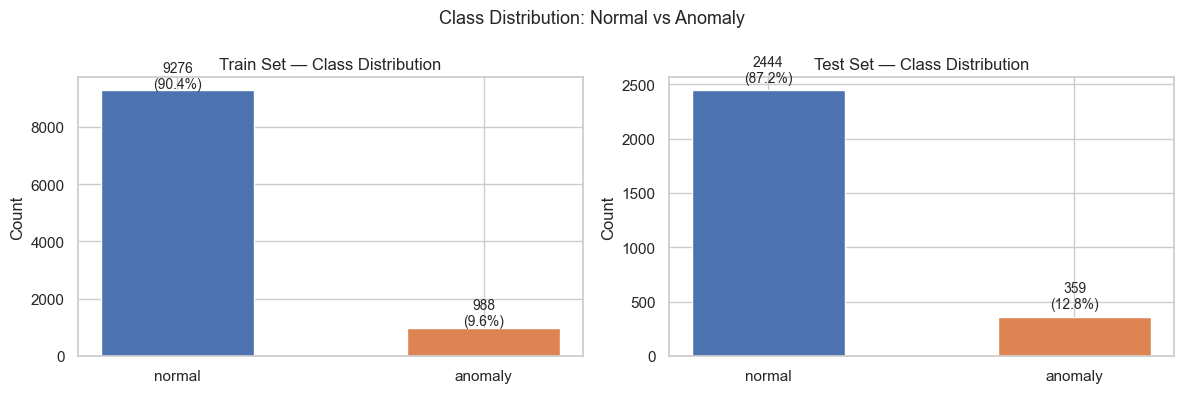

Class imbalance ratio (train): 9.4:1
-> Random oversampling will be applied to balance classes


In [41]:
sns.set_theme(style='whitegrid', palette='muted')

# 6.1 Class distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, df, title in zip(axes, [train_raw, test_raw], ['Train', 'Test']):
    counts = df['class'].value_counts()
    bars = ax.bar(counts.index, counts.values,
                  color=['#4C72B0', '#DD8452'], width=0.5)
    ax.set_title(f'{title} Set — Class Distribution', fontsize=12)
    ax.set_ylabel('Count')
    for bar, v in zip(bars, counts.values):
        ax.text(bar.get_x() + bar.get_width() / 2, v + 80,
                f'{v}\n({v / len(df) * 100:.1f}%)',
                ha='center', fontsize=10)
plt.suptitle('Class Distribution: Normal vs Anomaly', fontsize=13)
plt.tight_layout()
plt.show()

ratio = (train_raw['label_bin'].value_counts()[0]
       / train_raw['label_bin'].value_counts()[1])
print(f'Class imbalance ratio (train): {ratio:.1f}:1')
print('-> Random oversampling will be applied to balance classes')

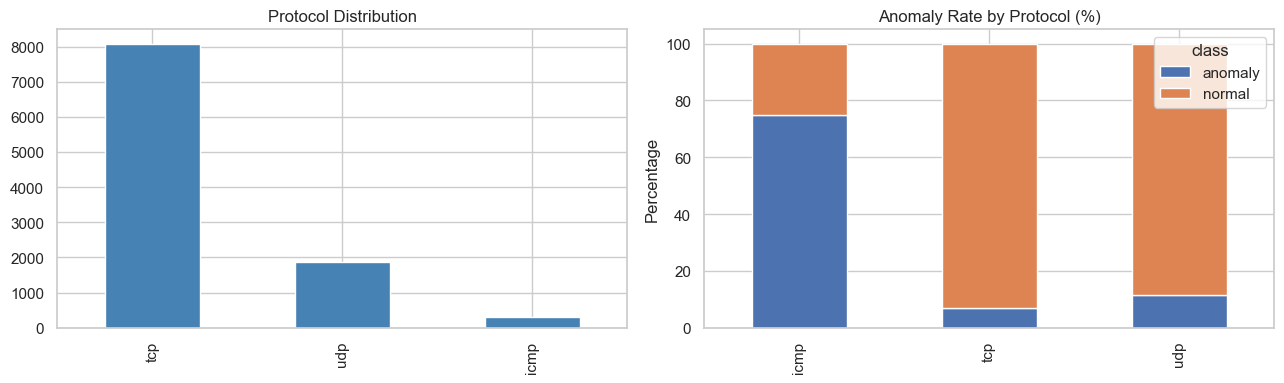

In [42]:
# 6.2 Protocol distribution + anomaly rate by protocol
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

train_raw['protocol'].value_counts().plot.bar(
    ax=axes[0], color='steelblue')
axes[0].set_title('Protocol Distribution')
axes[0].set_xlabel('')

ct = (pd.crosstab(train_raw['protocol'], train_raw['class'],
                  normalize='index') * 100)
ct.plot.bar(ax=axes[1], stacked=True,
            color=['#4C72B0', '#DD8452'])
axes[1].set_title('Anomaly Rate by Protocol (%)')
axes[1].set_ylabel('Percentage')
axes[1].set_xlabel('')
plt.tight_layout()
plt.show()

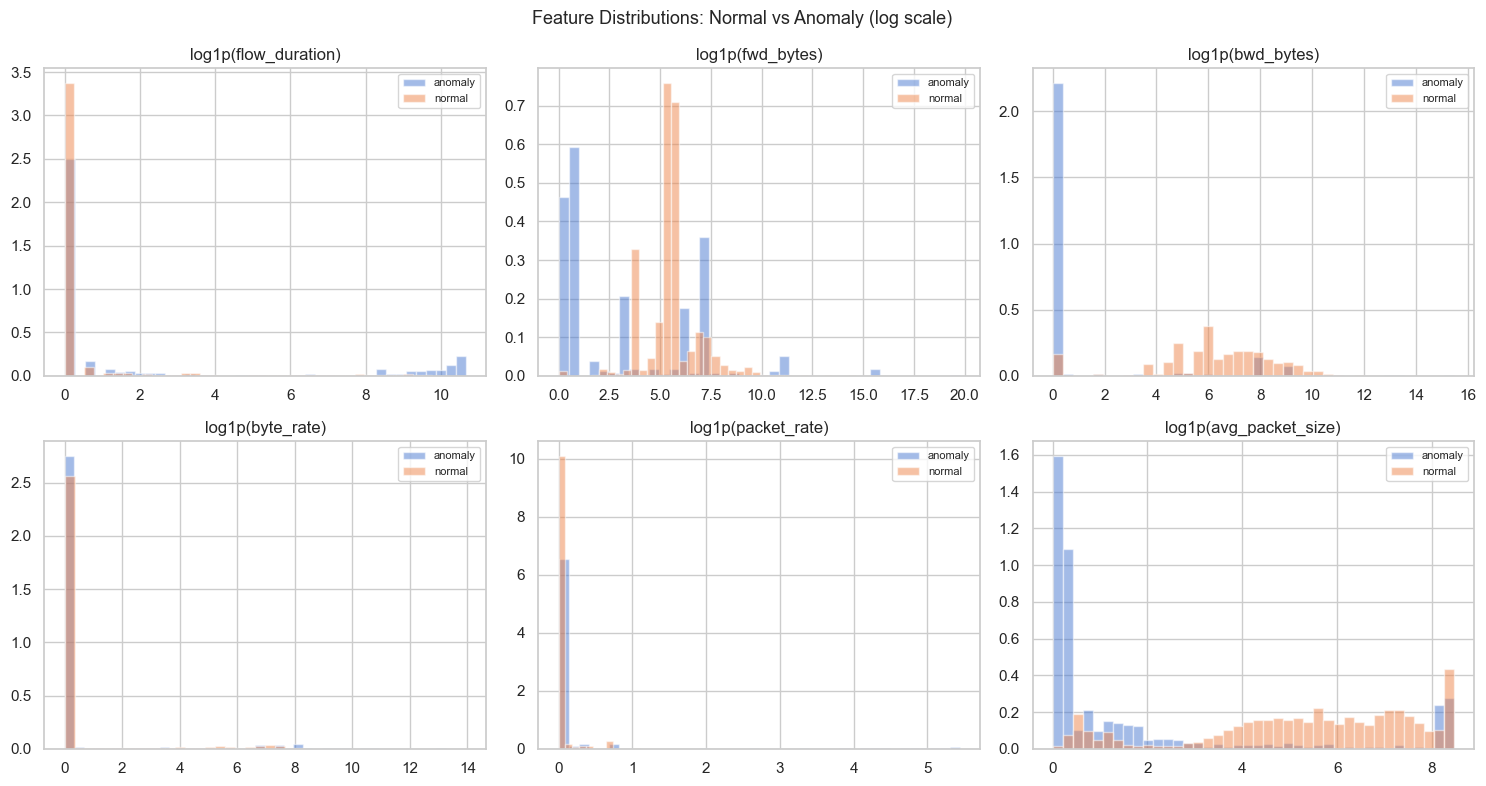

In [43]:
# 6.3 Feature distributions by class (log scale)
num_features = ['flow_duration', 'fwd_bytes', 'bwd_bytes',
                'byte_rate', 'packet_rate', 'avg_packet_size']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, col in zip(axes.flat, num_features):
    for label, grp in train_raw.groupby('class'):
        ax.hist(np.log1p(grp[col]), bins=40,
                alpha=0.5, label=label, density=True)
    ax.set_title(f'log1p({col})')
    ax.legend(fontsize=8)
plt.suptitle('Feature Distributions: Normal vs Anomaly (log scale)', fontsize=13)
plt.tight_layout()
plt.show()

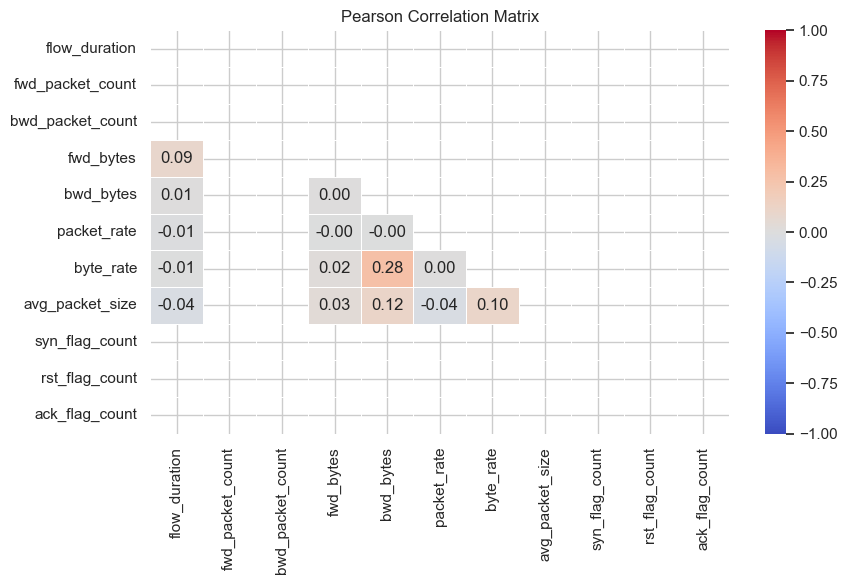

In [44]:
# 6.4 Pearson correlation heatmap
num_cols = (train_raw
            .select_dtypes(include=np.number)
            .drop(columns=['label_bin'])
            .columns)
corr = train_raw[num_cols].corr()

plt.figure(figsize=(9, 6))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f',
            cmap='coolwarm', linewidths=0.5, vmin=-1, vmax=1)
plt.title('Pearson Correlation Matrix')
plt.tight_layout()
plt.show()

In [45]:
# 6.5 Feature means: Normal vs Anomaly
summary = train_raw.groupby('class')[num_features].mean().T
summary['ratio (anomaly/normal)'] = (
    summary['anomaly'] / summary['normal'].replace(0, np.nan)
).round(1)
print('Feature means by class:')
print(summary.to_string())

Feature means by class:
class                  anomaly       normal  ratio (anomaly/normal)
flow_duration      4490.580972   215.587214                    20.8
fwd_bytes        435071.778340  3984.524580                   109.2
bwd_bytes         17285.855263  4702.224450                     3.7
byte_rate          1863.114890  1080.351813                     1.7
packet_rate           5.195190     0.051940                   100.0
avg_packet_size     488.649743   981.062661                     0.5


---
## 7. Preprocessing Pipeline

In [46]:
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.utils import resample

# 7.1 Drop zero-variance features
# These 5 are constant 0 in NSL-KDD — per-packet TCP flag
# counts and directional packet counts are not captured
ZERO_VAR = [
    'fwd_packet_count', 'bwd_packet_count',
    'syn_flag_count',   'rst_flag_count',   'ack_flag_count'
]
train = train_raw.drop(columns=ZERO_VAR).copy()
test  = test_raw.drop(columns=ZERO_VAR).copy()

print(f'Dropped zero-variance: {ZERO_VAR}')
print(f'Remaining columns    : {train.shape[1]}')

Dropped zero-variance: ['fwd_packet_count', 'bwd_packet_count', 'syn_flag_count', 'rst_flag_count', 'ack_flag_count']
Remaining columns    : 10


In [47]:
# 7.2 Label-encode categorical features
# Fit on combined train + test vocabulary so that 10 unseen
# service_state values in test do not raise errors at inference
le_proto = LabelEncoder()
le_svc   = LabelEncoder()

le_proto.fit(
    pd.concat([train['protocol'], test['protocol']]).unique())
le_svc.fit(
    pd.concat([train['service_state'], test['service_state']]).unique())

for df in [train, test]:
    df['protocol']      = le_proto.transform(df['protocol'])
    df['service_state'] = le_svc.transform(df['service_state'])

print(f'protocol classes    : {le_proto.classes_}')
print(f'service_state vocab : {len(le_svc.classes_)} unique values')

protocol classes    : ['icmp' 'tcp' 'udp']
service_state vocab : 232 unique values


In [48]:
# 7.3 Log1p transformation
# Reduces right skew — anomaly traffic has extreme byte values
# e.g. fwd_bytes up to 693 million in flood attacks
LOG_COLS = [
    'flow_duration', 'fwd_bytes',   'bwd_bytes',
    'packet_rate',   'byte_rate',   'avg_packet_size'
]
for col in LOG_COLS:
    train[f'log_{col}'] = np.log1p(train[col])
    test[f'log_{col}']  = np.log1p(test[col])

print('log1p transformation applied ✓')

log1p transformation applied ✓


In [49]:
# 7.4 Feature matrix and target
FEATURE_COLS = [f'log_{c}' for c in LOG_COLS] + ['protocol', 'service_state']

X_train = train[FEATURE_COLS]
y_train = train['label_bin']
X_test  = test[FEATURE_COLS]
y_test  = test['label_bin']

print(f'Features ({len(FEATURE_COLS)}): {FEATURE_COLS}')
print(f'X_train : {X_train.shape}  |  X_test : {X_test.shape}')

Features (8): ['log_flow_duration', 'log_fwd_bytes', 'log_bwd_bytes', 'log_packet_rate', 'log_byte_rate', 'log_avg_packet_size', 'protocol', 'service_state']
X_train : (10264, 8)  |  X_test : (2803, 8)


In [50]:
# 7.5 StandardScaler — fit on train only, apply to both
scaler    = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

print('StandardScaler applied ✓')

StandardScaler applied ✓


In [51]:
# 7.6 Random oversampling — balance 9.4:1 class imbalance
# Uses sklearn.utils.resample to duplicate minority class
# records until both classes are equal size.
# Applied to scaled training set ONLY — never to test data.
RANDOM_STATE = 42

print(f'Before oversampling : {dict(pd.Series(y_train).value_counts())}')

# Combine scaled features + labels into one DataFrame
train_scaled_df = pd.DataFrame(X_train_s, columns=FEATURE_COLS)
train_scaled_df['label_bin'] = y_train.values

majority = train_scaled_df[train_scaled_df['label_bin'] == 0]
minority = train_scaled_df[train_scaled_df['label_bin'] == 1]

# Upsample minority class to match majority size
minority_upsampled = resample(
    minority,
    replace     = True,
    n_samples   = len(majority),
    random_state= RANDOM_STATE
)

train_balanced = pd.concat([majority, minority_upsampled])

X_res = train_balanced[FEATURE_COLS].values
y_res = train_balanced['label_bin'].values

print(f'After  oversampling : {dict(pd.Series(y_res).value_counts())}')

Before oversampling : {0: np.int64(9276), 1: np.int64(988)}
After  oversampling : {0: np.int64(9276), 1: np.int64(9276)}


---
## 8. Model Training & 5-Fold Cross-Validation

In [52]:
from sklearn.linear_model    import LogisticRegression
from sklearn.naive_bayes     import GaussianNB
from sklearn.neighbors       import KNeighborsClassifier
from sklearn.tree            import DecisionTreeClassifier
from sklearn.ensemble        import RandomForestClassifier
from sklearn.svm             import SVC
from sklearn.model_selection import cross_val_score, StratifiedKFold

# 8.1 Define all six classifiers
models = {
    'Logistic Regression' : LogisticRegression(
                                max_iter=500,
                                random_state=RANDOM_STATE),
    'Naive Bayes'         : GaussianNB(),
    'KNN'                 : KNeighborsClassifier(n_neighbors=5),
    'Decision Tree'       : DecisionTreeClassifier(
                                random_state=RANDOM_STATE),
    'Random Forest'       : RandomForestClassifier(
                                n_estimators=100,
                                random_state=RANDOM_STATE,
                                n_jobs=-1),
    'SVM'                 : SVC(
                                probability=True,
                                random_state=RANDOM_STATE),
}

In [53]:
# 8.2 Stratified 5-fold CV on oversampled training set
cv = StratifiedKFold(n_splits=5, shuffle=True,
                     random_state=RANDOM_STATE)
cv_results = {}

for name, model in models.items():
    scores = cross_val_score(
        model, X_res, y_res,
        cv=cv, scoring='f1', n_jobs=-1
    )
    cv_results[name] = scores
    print(f'{name:22s}  CV F1 = {scores.mean():.4f} +/- {scores.std():.4f}')

Logistic Regression     CV F1 = 0.8995 +/- 0.0053
Naive Bayes             CV F1 = 0.9051 +/- 0.0058
KNN                     CV F1 = 0.9939 +/- 0.0005
Decision Tree           CV F1 = 0.9969 +/- 0.0007
Random Forest           CV F1 = 0.9978 +/- 0.0007
SVM                     CV F1 = 0.9767 +/- 0.0043


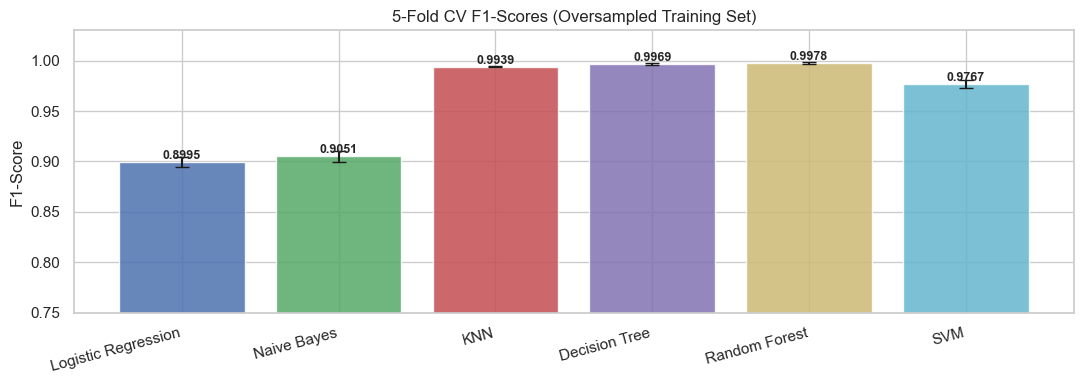

In [54]:
# 8.3 CV scores bar chart
fig, ax = plt.subplots(figsize=(11, 4))
names  = list(cv_results.keys())
means  = [v.mean() for v in cv_results.values()]
stds   = [v.std()  for v in cv_results.values()]
colors = ['#4C72B0','#55A868','#C44E52',
          '#8172B2','#CCB974','#64B5CD']

bars = ax.bar(names, means, yerr=stds,
              capsize=5, color=colors, alpha=0.85)
ax.set_ylim(0.75, 1.03)
ax.set_ylabel('F1-Score')
ax.set_title('5-Fold CV F1-Scores (Oversampled Training Set)')
ax.set_xticklabels(names, rotation=15, ha='right')
for bar, m in zip(bars, means):
    ax.text(bar.get_x() + bar.get_width() / 2, m + 0.003,
            f'{m:.4f}', ha='center', fontsize=9, fontweight='bold')
plt.tight_layout()
plt.show()

In [55]:
# 8.4 Train each model on the full oversampled training set
trained = {}
for name, model in models.items():
    model.fit(X_res, y_res)
    trained[name] = model
    print(f'{name:22s} trained ✓')

Logistic Regression    trained ✓
Naive Bayes            trained ✓
KNN                    trained ✓
Decision Tree          trained ✓
Random Forest          trained ✓
SVM                    trained ✓


---
## 9. Evaluation on Hold-Out Test Set

In [56]:
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, roc_curve,
    accuracy_score, f1_score, precision_score, recall_score
)

# 9.1 Collect all metrics
metrics_rows = []
all_preds    = {}
all_probas   = {}

for name, model in trained.items():
    preds = model.predict(X_test_s)
    proba = model.predict_proba(X_test_s)[:, 1]
    all_preds[name]  = preds
    all_probas[name] = proba
    metrics_rows.append({
        'Model'    : name,
        'Accuracy' : accuracy_score(y_test, preds),
        'Precision': precision_score(y_test, preds),
        'Recall'   : recall_score(y_test, preds),
        'F1-Score' : f1_score(y_test, preds),
        'AUC-ROC'  : roc_auc_score(y_test, proba),
    })

metrics_df = pd.DataFrame(metrics_rows).set_index('Model')
print(metrics_df.to_string(float_format='{:.4f}'.format))

                     Accuracy  Precision  Recall  F1-Score  AUC-ROC
Model                                                              
Logistic Regression    0.8980     0.5628  0.9109    0.6957   0.9364
Naive Bayes            0.9026     0.5760  0.9081    0.7049   0.9466
KNN                    0.9850     0.9054  0.9861    0.9440   0.9948
Decision Tree          0.9918     0.9590  0.9777    0.9683   0.9871
Random Forest          0.9939     0.9698  0.9833    0.9765   0.9980
SVM                    0.9818     0.8869  0.9833    0.9326   0.9948


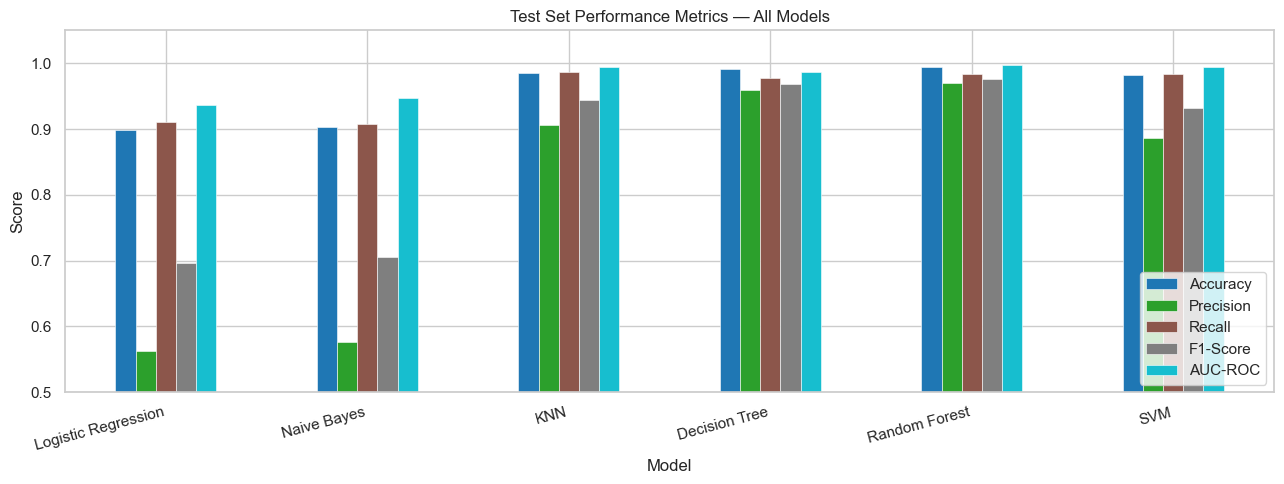

In [57]:
# 9.2 Performance bar chart
metrics_df.plot.bar(
    figsize=(13, 5), ylim=(0.5, 1.05),
    colormap='tab10', edgecolor='white', linewidth=0.4
)
plt.title('Test Set Performance Metrics — All Models')
plt.ylabel('Score')
plt.xticks(rotation=15, ha='right')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

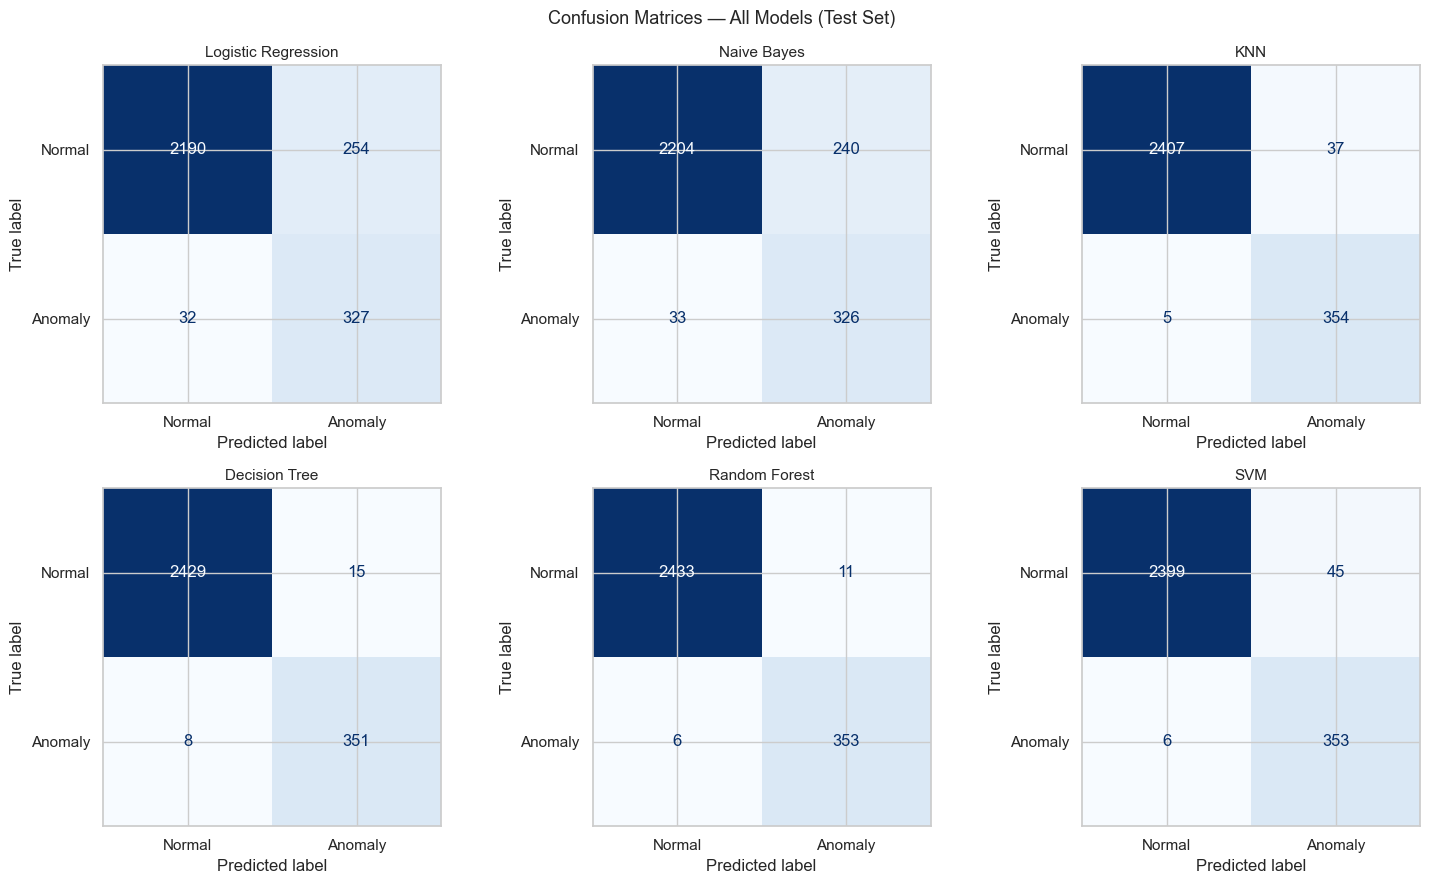

In [58]:
# 9.3 Confusion matrices — all six models
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
for ax, (name, preds) in zip(axes.flat, all_preds.items()):
    cm = confusion_matrix(y_test, preds)
    ConfusionMatrixDisplay(
        cm, display_labels=['Normal', 'Anomaly']
    ).plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(name, fontsize=11)
plt.suptitle('Confusion Matrices — All Models (Test Set)', fontsize=13)
plt.tight_layout()
plt.show()

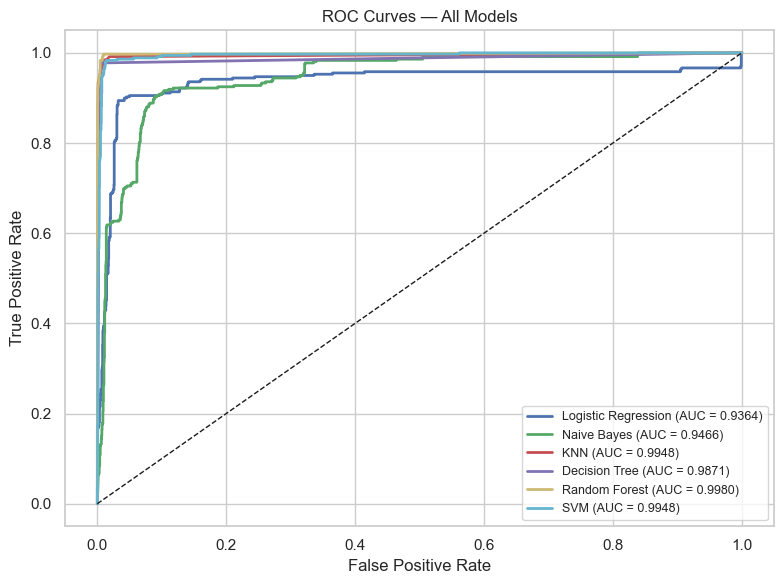

In [59]:
# 9.4 ROC curves
plt.figure(figsize=(8, 6))
colors = ['#4C72B0','#55A868','#C44E52',
          '#8172B2','#CCB974','#64B5CD']
for (name, proba), color in zip(all_probas.items(), colors):
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    plt.plot(fpr, tpr,
             label=f'{name} (AUC = {auc:.4f})',
             color=color, lw=2)
plt.plot([0, 1], [0, 1], 'k--', lw=1)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves — All Models')
plt.legend(loc='lower right', fontsize=9)
plt.tight_layout()
plt.show()

In [60]:
# 9.5 Full classification reports
for name, preds in all_preds.items():
    print(f'\n=== {name} ===')
    print(classification_report(
        y_test, preds,
        target_names=['Normal', 'Anomaly']
    ))


=== Logistic Regression ===
              precision    recall  f1-score   support

      Normal       0.99      0.90      0.94      2444
     Anomaly       0.56      0.91      0.70       359

    accuracy                           0.90      2803
   macro avg       0.77      0.90      0.82      2803
weighted avg       0.93      0.90      0.91      2803


=== Naive Bayes ===
              precision    recall  f1-score   support

      Normal       0.99      0.90      0.94      2444
     Anomaly       0.58      0.91      0.70       359

    accuracy                           0.90      2803
   macro avg       0.78      0.90      0.82      2803
weighted avg       0.93      0.90      0.91      2803


=== KNN ===
              precision    recall  f1-score   support

      Normal       1.00      0.98      0.99      2444
     Anomaly       0.91      0.99      0.94       359

    accuracy                           0.99      2803
   macro avg       0.95      0.99      0.97      2803
weighted av

---
## 10. Without Oversampling — Comparison

In [61]:
# 10.1 Train same six models on original imbalanced training set
no_os_rows = []

models_no_os = {
    'Logistic Regression' : LogisticRegression(
                                max_iter=500,
                                random_state=RANDOM_STATE),
    'Naive Bayes'         : GaussianNB(),
    'KNN'                 : KNeighborsClassifier(n_neighbors=5),
    'Decision Tree'       : DecisionTreeClassifier(
                                random_state=RANDOM_STATE),
    'Random Forest'       : RandomForestClassifier(
                                n_estimators=100,
                                random_state=RANDOM_STATE,
                                n_jobs=-1),
    'SVM'                 : SVC(
                                probability=True,
                                random_state=RANDOM_STATE),
}

for name, model in models_no_os.items():
    model.fit(X_train_s, y_train)
    p  = model.predict(X_test_s)
    pr = model.predict_proba(X_test_s)[:, 1]
    no_os_rows.append({
        'Model'    : name,
        'Accuracy' : accuracy_score(y_test, p),
        'Precision': precision_score(y_test, p),
        'Recall'   : recall_score(y_test, p),
        'F1-Score' : f1_score(y_test, p),
        'AUC-ROC'  : roc_auc_score(y_test, pr),
    })

no_os_df = pd.DataFrame(no_os_rows).set_index('Model')
print('Without oversampling:')
print(no_os_df.to_string(float_format='{:.4f}'.format))

Without oversampling:
                     Accuracy  Precision  Recall  F1-Score  AUC-ROC
Model                                                              
Logistic Regression    0.9504     0.8235  0.7799    0.8011   0.9357
Naive Bayes            0.9179     0.6308  0.8663    0.7300   0.9465
KNN                    0.9900     0.9662  0.9554    0.9608   0.9951
Decision Tree          0.9907     0.9798  0.9471    0.9632   0.9915
Random Forest          0.9932     0.9775  0.9694    0.9734   0.9982
SVM                    0.9875     0.9629  0.9387    0.9506   0.9946


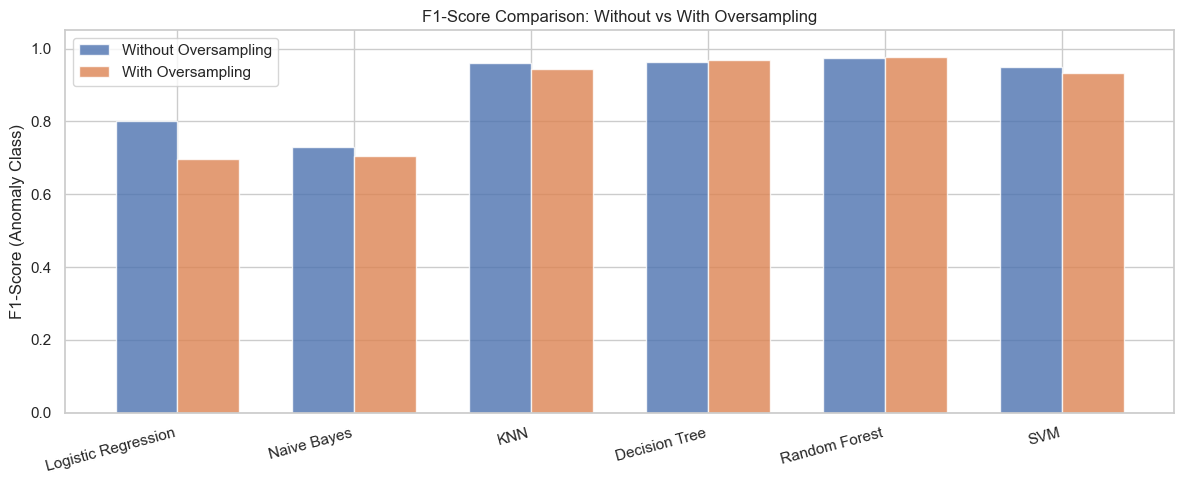

In [62]:
# 10.2 Side-by-side F1 comparison
fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(models))
w = 0.35
ax.bar(x - w / 2, no_os_df['F1-Score'], w,
       label='Without Oversampling', color='#4C72B0', alpha=0.8)
ax.bar(x + w / 2, metrics_df['F1-Score'], w,
       label='With Oversampling',    color='#DD8452', alpha=0.8)
ax.set_xticks(x)
ax.set_xticklabels(list(models.keys()), rotation=15, ha='right')
ax.set_ylabel('F1-Score (Anomaly Class)')
ax.set_title('F1-Score Comparison: Without vs With Oversampling')
ax.set_ylim(0, 1.05)
ax.legend()
plt.tight_layout()
plt.show()

---
## 11. Feature Importance (Random Forest)

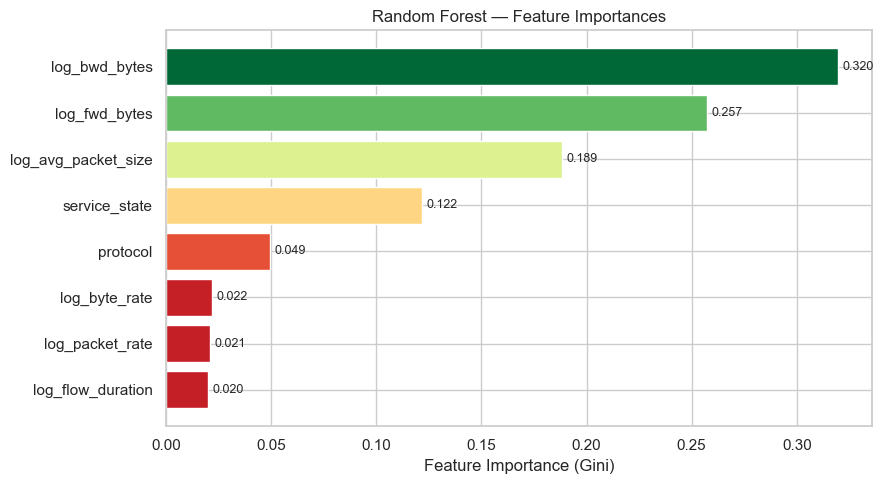

Top 5 most important features:
  log_bwd_bytes               : 0.3196
  log_fwd_bytes               : 0.2574
  log_avg_packet_size         : 0.1885
  service_state               : 0.1220
  protocol                    : 0.0494


In [63]:
rf_model = trained['Random Forest']
fi = pd.Series(
    rf_model.feature_importances_,
    index=FEATURE_COLS
).sort_values(ascending=True)

plt.figure(figsize=(9, 5))
bar_colors = plt.cm.RdYlGn(fi.values / fi.values.max())
bars = plt.barh(fi.index, fi.values, color=bar_colors)
plt.xlabel('Feature Importance (Gini)')
plt.title('Random Forest — Feature Importances')
for bar, val in zip(bars, fi.values):
    plt.text(val + 0.002,
             bar.get_y() + bar.get_height() / 2,
             f'{val:.3f}', va='center', fontsize=9)
plt.tight_layout()
plt.show()

print('Top 5 most important features:')
for feat, imp in fi.sort_values(ascending=False).head(5).items():
    print(f'  {feat:28s}: {imp:.4f}')

---
## 12. Final Summary

In [64]:
print('=' * 65)
print('  FINAL RESULTS — With Oversampling  |  Test set n = 2,803')
print('=' * 65)
print(metrics_df.to_string(float_format='{:.4f}'.format))
print('=' * 65)

best = metrics_df['F1-Score'].idxmax()
row  = metrics_df.loc[best]
print(f'\n  Best model  : {best}')
print(f'  Accuracy    : {row["Accuracy"]:.4f}')
print(f'  Precision   : {row["Precision"]:.4f}')
print(f'  Recall      : {row["Recall"]:.4f}')
print(f'  F1-Score    : {row["F1-Score"]:.4f}')
print(f'  AUC-ROC     : {row["AUC-ROC"]:.4f}')
print()
print('  Pipeline summary')
print('  Data source   : MySQL  nsl_kdd -> nsl_kdd_common_train/test_clean')
print('  Dropped       : 5 zero-variance features')
print('  Encoding      : LabelEncoder on protocol + service_state')
print('  Transform     : log1p on 6 continuous features')
print('  Scaling       : StandardScaler (fit on train only)')
print('  Oversampling  : sklearn.utils.resample  9.4:1 -> 1:1  (18,552 samples)')

  FINAL RESULTS — With Oversampling  |  Test set n = 2,803
                     Accuracy  Precision  Recall  F1-Score  AUC-ROC
Model                                                              
Logistic Regression    0.8980     0.5628  0.9109    0.6957   0.9364
Naive Bayes            0.9026     0.5760  0.9081    0.7049   0.9466
KNN                    0.9850     0.9054  0.9861    0.9440   0.9948
Decision Tree          0.9918     0.9590  0.9777    0.9683   0.9871
Random Forest          0.9939     0.9698  0.9833    0.9765   0.9980
SVM                    0.9818     0.8869  0.9833    0.9326   0.9948

  Best model  : Random Forest
  Accuracy    : 0.9939
  Precision   : 0.9698
  Recall      : 0.9833
  F1-Score    : 0.9765
  AUC-ROC     : 0.9980

  Pipeline summary
  Data source   : MySQL  nsl_kdd -> nsl_kdd_common_train/test_clean
  Dropped       : 5 zero-variance features
  Encoding      : LabelEncoder on protocol + service_state
  Transform     : log1p on 6 continuous features
  Scaling   